<a href="https://colab.research.google.com/github/PraeyOfTheGods/sephora-skincare-recommendation-week1-/blob/main/notebooks/03_text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Skincare Concern Findings

Keyword-based analysis was used to identify common skincare concerns mentioned in the usable review text.

Key findings:

- **Dryness** was the most frequently detected concern, appearing in 20.59% of reviews.
- **Redness** was mentioned in 17.33% of reviews, followed by **oiliness** at 16.34%.
- **Acne** appeared in 13.38% of reviews, while **sensitivity** and **texture** appeared in 12.60% and 12.52%, respectively.
- Aging-related terms appeared in 9.14% of reviews.
- Pores, dark spots, and dullness were mentioned less frequently.
- Because keyword groups can overlap, a review may be counted under multiple concerns.
- These concern indicators can later support personalized skincare recommendations when combined with skin type, product characteristics, sentiment, and customer preferences.

In [52]:
concern_summary.to_csv(
    "/content/skincare_concerns.csv",
    index=False
)

print("Saved:", "/content/skincare_concerns.csv")

Saved: /content/skincare_concerns.csv


In [51]:
total_reviews = len(nlp_reviews)

concern_summary["percentage"] = (
    concern_summary["review_count"] / total_reviews * 100
).round(2)

concern_summary

,concern,review_count,percentage
0,Dryness,225073,20.59
3,Redness,189442,17.33
2,Oiliness,178639,16.34
1,Acne,146260,13.38
4,Sensitivity,137704,12.60
9,Texture,136888,12.52
5,Aging,99880,9.14
7,Pores,64632,5.91
6,Dark Spots,24834,2.27
8,Dullness,23489,2.15


In [50]:
concern_keywords = {
    "Dryness": ["dry", "dryness", "dehydrated", "dehydration"],
    "Acne": ["acne", "breakout", "breakouts", "pimple", "pimples"],
    "Oiliness": ["oily", "oil", "sebum"],
    "Redness": ["redness", "red", "rosacea"],
    "Sensitivity": ["sensitive", "sensitivity", "irritation", "irritated"],
    "Aging": ["aging", "ageing", "wrinkle", "wrinkles", "fine lines"],
    "Dark Spots": ["dark spot", "dark spots", "hyperpigmentation", "pigmentation"],
    "Pores": ["pore", "pores", "large pores"],
    "Dullness": ["dull", "dullness", "brightening", "brightness"],
    "Texture": ["texture", "uneven texture", "rough"]
}

concern_counts = {}

for concern, keywords in concern_keywords.items():
    pattern = "|".join(re.escape(keyword) for keyword in keywords)
    concern_counts[concern] = nlp_reviews["final_text"].str.contains(
        pattern,
        case=False,
        regex=True,
        na=False
    ).sum()

concern_summary = pd.DataFrame(
    list(concern_counts.items()),
    columns=["concern", "review_count"]
).sort_values(
    "review_count",
    ascending=False
)

concern_summary

,concern,review_count
0,Dryness,225073
3,Redness,189442
2,Oiliness,178639
1,Acne,146260
4,Sensitivity,137704
9,Texture,136888
5,Aging,99880
7,Pores,64632
6,Dark Spots,24834
8,Dullness,23489


## TF-IDF Findings

TF-IDF was applied to a sample of 100,000 reviews to identify prominent terms and phrases in the review text.

Key findings:

- The most prominent term was **"skin"**, followed by **"product"**, **"love"**, **"use"**, and **"like"**.
- Skin-related terms such as **"face"**, **"dry"**, **"moisturizer"**, and **"cream"** were prominent in the reviews.
- Satisfaction-related terms such as **"love"**, **"great"**, **"good"**, **"amazing"**, and **"recommend"** were also common.
- These results indicate that review text contains useful information about product experience, skin concerns, product usage, and customer satisfaction.
- TF-IDF features can be used as input features for later text-based analysis and predictive modeling.

In [49]:
top_tfidf.to_csv(
    "/content/top_tfidf_terms.csv",
    index=False
)

print("Saved:", "/content/top_tfidf_terms.csv")

Saved: /content/top_tfidf_terms.csv


In [48]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

tfidf_matrix = tfidf_vectorizer.fit_transform(tfidf_sample)

feature_names = tfidf_vectorizer.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

top_tfidf = pd.DataFrame({
    "term": feature_names,
    "tfidf_score": mean_tfidf
}).sort_values(
    "tfidf_score",
    ascending=False
).head(30)

top_tfidf

,term,tfidf_score
3830,skin,0.054621
3194,product,0.037072
2464,love,0.030341
4617,use,0.025365
2294,like,0.024658
1260,face,0.024544
3412,really,0.022042
4709,using,0.021443
1736,great,0.019488
1096,dry,0.018313


In [47]:
import numpy as np

feature_names = tfidf_vectorizer.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

top_tfidf = pd.DataFrame({
    "term": feature_names,
    "tfidf_score": mean_tfidf
}).sort_values(
    "tfidf_score",
    ascending=False
).head(30)

top_tfidf

,term,tfidf_score
2076,it,0.060728
181,and,0.060427
4107,the,0.056026
2699,my,0.052490
4275,this,0.048126
3670,skin,0.042316
4399,to,0.039492
1996,is,0.035662
1464,for,0.031324
3244,product,0.028461


In [46]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

tfidf_matrix = tfidf_vectorizer.fit_transform(tfidf_sample)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (100000, 5000)


## Text Analytics Findings

The review text was cleaned through lowercasing, URL removal, punctuation cleaning, tokenization, stopword removal, and contraction handling while preserving negation.

VADER sentiment analysis was then applied to 1,092,931 usable reviews.

Key findings:

- 90.26% of reviews were classified as positive, 6.65% as negative, and 3.09% as neutral.
- Average sentiment increased with review rating, from 0.168 for 1-star reviews to 0.747 for 5-star reviews.
- Recommended reviews had a much higher average sentiment score (0.751) than non-recommended reviews (0.363).
- Average sentiment was relatively similar across skin types: normal (0.691), combination (0.688), dry (0.685), and oily (0.671).
- The strong relationship between sentiment and rating/recommendation suggests that review text contains useful information about customer satisfaction.
- The relatively small differences across skin types suggest that sentiment alone may not be sufficient for personalization and should be combined with customer profile and product information.

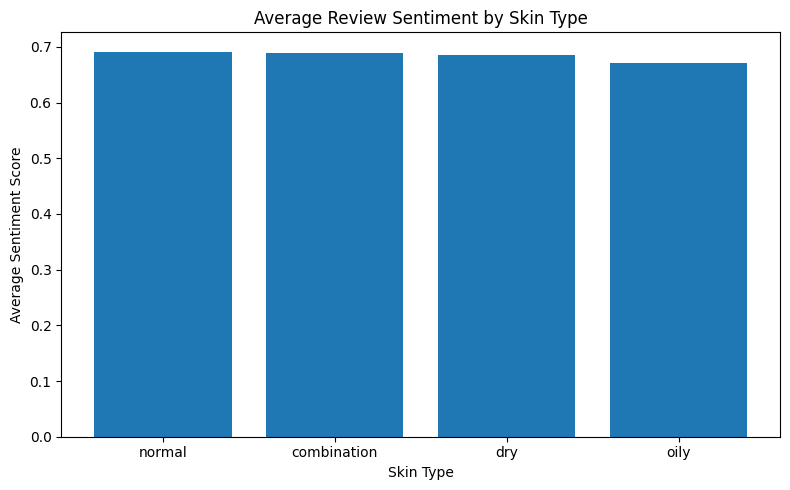

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    sentiment_by_skin_type["skin_type"],
    sentiment_by_skin_type["sentiment"]
)

plt.title("Average Review Sentiment by Skin Type")
plt.xlabel("Skin Type")
plt.ylabel("Average Sentiment Score")
plt.tight_layout()
plt.show()

In [24]:
sentiment_by_skin_type = (
    nlp_reviews.dropna(subset=["skin_type"])
    .groupby("skin_type")["sentiment"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sentiment_by_skin_type

,skin_type,sentiment
0,normal,0.691434
1,combination,0.688121
2,dry,0.684988
3,oily,0.671290


In [25]:
sentiment_summary = pd.DataFrame({
    "Sentiment": nlp_reviews["sentiment_label"].value_counts().index,
    "Review_Count": nlp_reviews["sentiment_label"].value_counts().values
})

sentiment_summary["Percentage"] = (
    sentiment_summary["Review_Count"]
    / sentiment_summary["Review_Count"].sum()
    * 100
).round(2)

sentiment_summary

,Sentiment,Review_Count,Percentage
0,Positive,986496,90.26
1,Negative,72693,6.65
2,Neutral,33742,3.09


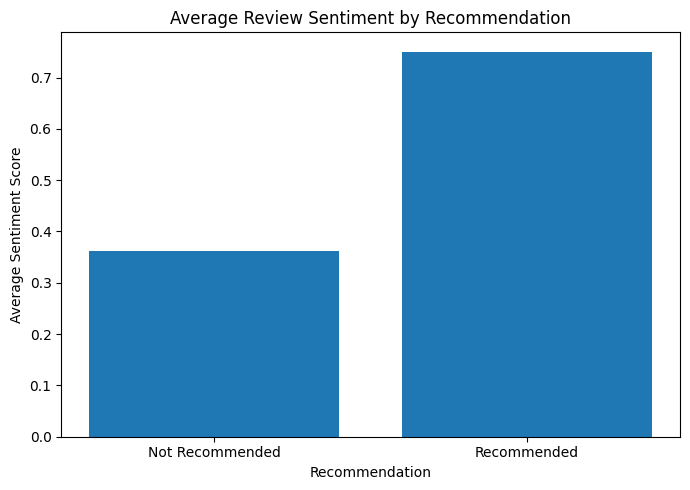

In [26]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Not Recommended", "Recommended"],
    sentiment_by_recommendation["sentiment"]
)

plt.title("Average Review Sentiment by Recommendation")
plt.xlabel("Recommendation")
plt.ylabel("Average Sentiment Score")
plt.tight_layout()
plt.show()

In [27]:
sentiment_by_recommendation = (
    nlp_reviews.groupby("is_recommended")["sentiment"]
    .mean()
    .reset_index()
)

sentiment_by_recommendation

,is_recommended,sentiment
0,0.0,0.362887
1,1.0,0.750520


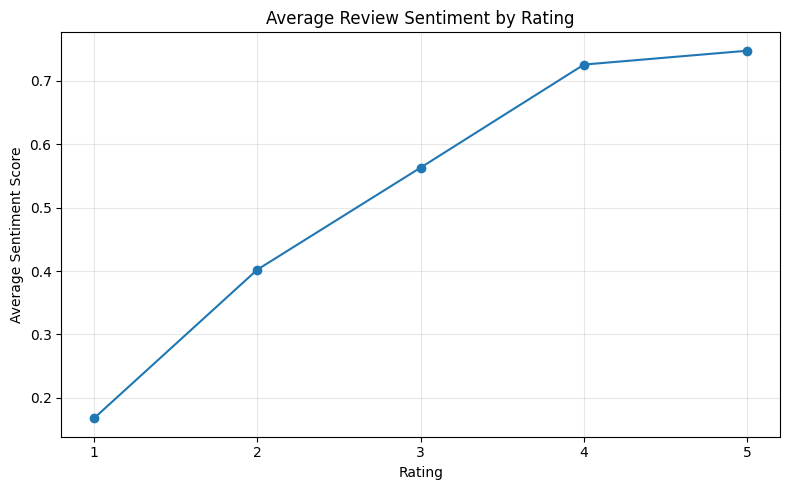

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    sentiment_by_rating["rating"],
    sentiment_by_rating["sentiment"],
    marker="o"
)

plt.title("Average Review Sentiment by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Sentiment Score")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [29]:
sentiment_by_rating = (
    nlp_reviews.groupby("rating")["sentiment"]
    .mean()
    .reset_index()
)

sentiment_by_rating

,rating,sentiment
0,1,0.167712
1,2,0.402163
2,3,0.563113
3,4,0.725596
4,5,0.747430


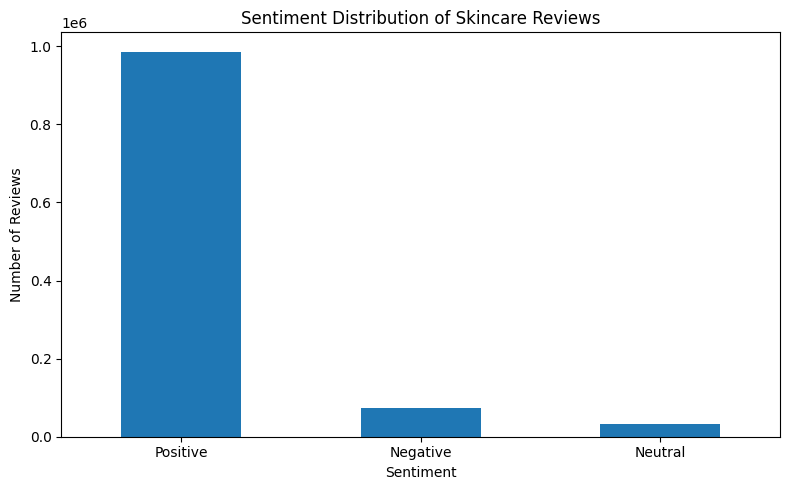

In [30]:
import matplotlib.pyplot as plt

sentiment_counts = nlp_reviews["sentiment_label"].value_counts()

plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution of Skincare Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
def sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

nlp_reviews["sentiment_label"] = nlp_reviews["sentiment"].apply(
    sentiment_label
)

print(nlp_reviews["sentiment_label"].value_counts())

print("\nPercentage distribution:")
print(
    nlp_reviews["sentiment_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_label
Positive    986496
Negative     72693
Neutral      33742
Name: count, dtype: int64

Percentage distribution:
sentiment_label
Positive    90.26
Negative     6.65
Neutral      3.09
Name: proportion, dtype: float64


In [32]:
!pip install vaderSentiment -q

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

nlp_reviews["sentiment"] = nlp_reviews["final_text"].apply(
    lambda text: analyzer.polarity_scores(text)["compound"]
)

nlp_reviews[["final_text", "sentiment"]].head()

,final_text,sentiment
0,use nudestix citrus clean balm makeup melt dou...,0.9655
1,bought lip mask reading reviews hype unfortuna...,0.1280
2,review title says get excited get bed apply li...,-0.2732
3,i have always loved formula long time honestly...,0.9460
4,dry cracked lips must weeks use learned always...,0.2263


In [33]:
nlp_reviews["final_text"] = nlp_reviews["tokens_clean"].apply(
    lambda tokens: " ".join(tokens)
)

nlp_reviews[["clean_text", "final_text"]].head()

,clean_text,final_text
0,i use this with the nudestix citrus clean balm...,use nudestix citrus clean balm makeup melt dou...
1,i bought this lip mask after reading the revie...,bought lip mask reading reviews hype unfortuna...
2,my review title says it all i get so excited t...,review title says get excited get bed apply li...
3,ive always loved this formula for a long time ...,i have always loved formula long time honestly...
4,if you have dry cracked lips this is a must ha...,dry cracked lips must weeks use learned always...


In [34]:
contraction_map = {
    "ive": "i have",
    "im": "i am",
    "dont": "do not",
    "doesnt": "does not",
    "didnt": "did not",
    "isnt": "is not",
    "wasnt": "was not",
    "werent": "were not",
    "cant": "cannot",
    "couldnt": "could not",
    "wouldnt": "would not",
    "shouldnt": "should not",
    "wont": "will not",
    "havent": "have not",
    "hasnt": "has not",
    "hadnt": "had not"
}

nlp_reviews["tokens_clean"] = nlp_reviews["tokens"].apply(
    lambda tokens: [
        contraction_map.get(word, word)
        for word in tokens
    ]
)

nlp_reviews[["tokens", "tokens_clean"]].head()

,tokens,tokens_clean
0,"[use, nudestix, citrus, clean, balm, makeup, m...","[use, nudestix, citrus, clean, balm, makeup, m..."
1,"[bought, lip, mask, reading, reviews, hype, un...","[bought, lip, mask, reading, reviews, hype, un..."
2,"[review, title, says, get, excited, get, bed, ...","[review, title, says, get, excited, get, bed, ..."
3,"[ive, always, loved, formula, long, time, hone...","[i have, always, loved, formula, long, time, h..."
4,"[dry, cracked, lips, must, weeks, use, learned...","[dry, cracked, lips, must, weeks, use, learned..."


In [35]:
from collections import Counter

word_counts = Counter(
    word
    for tokens in nlp_reviews["tokens"]
    for word in tokens
)

top_words = pd.DataFrame(
    word_counts.most_common(30),
    columns=["word", "count"]
)

top_words

,word,count
0,skin,1276938
1,product,655403
2,love,415974
3,use,386871
4,like,360320
5,face,342659
6,using,304748
7,really,288865
8,dry,225320
9,great,214016


In [36]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

nlp_reviews["tokens"] = nlp_reviews["clean_text"].apply(
    lambda text: [
        word for word in text.split()
        if word not in stop_words
    ]
)

nlp_reviews[["clean_text", "tokens"]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,clean_text,tokens
0,i use this with the nudestix citrus clean balm...,"[use, nudestix, citrus, clean, balm, makeup, m..."
1,i bought this lip mask after reading the revie...,"[bought, lip, mask, reading, reviews, hype, un..."
2,my review title says it all i get so excited t...,"[review, title, says, get, excited, get, bed, ..."
3,ive always loved this formula for a long time ...,"[ive, always, loved, formula, long, time, hone..."
4,if you have dry cracked lips this is a must ha...,"[dry, cracked, lips, must, weeks, use, learned..."


In [37]:
nlp_reviews = reviews[reviews["clean_text_length"] >= 10].copy()

print("Original reviews:", len(reviews))
print("Reviews used for NLP:", len(nlp_reviews))
print("Reviews excluded from NLP:", len(reviews) - len(nlp_reviews))

Original reviews: 1094411
Reviews used for NLP: 1092931
Reviews excluded from NLP: 1480


In [38]:
reviews["clean_text_length"] = reviews["clean_text"].str.len()

print("Empty reviews:", (reviews["clean_text_length"] == 0).sum())
print("Reviews with fewer than 10 characters:",
      (reviews["clean_text_length"] < 10).sum())

Empty reviews: 1453
Reviews with fewer than 10 characters: 1480


In [39]:
import re

reviews["clean_text"] = reviews["review_text"].fillna("").astype(str)

reviews["clean_text"] = reviews["clean_text"].str.lower()

reviews["clean_text"] = reviews["clean_text"].apply(
    lambda x: re.sub(r"http\S+|www\S+", "", x)
)

reviews["clean_text"] = reviews["clean_text"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

reviews["clean_text"] = reviews["clean_text"].apply(
    lambda x: re.sub(r"[^\w\s']", "", x)
)

reviews[["review_text", "clean_text"]].head()

,review_text,clean_text
0,I use this with the Nudestix “Citrus Clean Bal...,i use this with the nudestix citrus clean balm...
1,I bought this lip mask after reading the revie...,i bought this lip mask after reading the revie...
2,My review title says it all! I get so excited ...,my review title says it all i get so excited t...
3,I’ve always loved this formula for a long time...,ive always loved this formula for a long time ...
4,"If you have dry cracked lips, this is a must h...",if you have dry cracked lips this is a must ha...


In [40]:
import pandas as pd

review_files = [
    "/content/reviews_0-250.csv",
    "/content/reviews_250-500.csv",
    "/content/reviews_500-750.csv",
    "/content/reviews_750-1250.csv",
    "/content/reviews_1250-end.csv"
]

reviews = pd.concat(
    [pd.read_csv(file, low_memory=False) for file in review_files],
    ignore_index=True
)

print("Combined review data shape:", reviews.shape)

Combined review data shape: (1094411, 19)


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_sample = nlp_reviews["final_text"].sample(
    n=100000,
    random_state=42
)

print("Reviews used for TF-IDF:", len(tfidf_sample))

Reviews used for TF-IDF: 100000


In [42]:
print(nlp_reviews.columns.tolist())

['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd', 'clean_text', 'clean_text_length']


In [43]:
nlp_reviews["final_text"] = nlp_reviews["clean_text"]

print("final_text column created.")
print(nlp_reviews["final_text"].head())

final_text column created.
0    i use this with the nudestix citrus clean balm...
1    i bought this lip mask after reading the revie...
2    my review title says it all i get so excited t...
3    ive always loved this formula for a long time ...
4    if you have dry cracked lips this is a must ha...
Name: final_text, dtype: object


In [ ]:
import re

reviews["clean_text"] = reviews["review_text"].fillna("").astype(str)

reviews["clean_text"] = reviews["clean_text"].str.lower()

reviews["clean_text"] = reviews["clean_text"].apply(
    lambda x: re.sub(r"http\S+|www\S+", "", x)
)

reviews["clean_text"] = reviews["clean_text"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

reviews[["review_text", "clean_text"]].head()

In [ ]:
print("Review text missing values:", reviews["review_text"].isna().sum())
print("Review titles missing values:", reviews["review_title"].isna().sum())

reviews[["review_title", "review_text"]].head()

In [ ]:
import pandas as pd

review_files = [
    "/content/reviews_0-250.csv",
    "/content/reviews_250-500.csv",
    "/content/reviews_500-750.csv",
    "/content/reviews_750-1250.csv",
    "/content/reviews_1250-end.csv"
]

reviews = pd.concat(
    [pd.read_csv(file) for file in review_files],
    ignore_index=True
)

print("Combined review data shape:", reviews.shape)